# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario Analysis** - (Optional) Compare a scenario against the baseline
5. **Export** - Save results and generate documentation

--- 

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [2]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), 'src')
sys.path.insert(0, src_path)

In [3]:
# Add ODYM framework to path
biodym_mfa_tool_dir = os.getcwd()
odym_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [4]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [5]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    from src import plotting
    import ODYM_Classes as msc
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [6]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [7]:
# This is the only manual path setting required.
input_file = "data/01_input/250910_CS1_Wheat_Straw_v3.xlsx"
print(f"📁 Input file: {input_file}")
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

📁 Input file: data/01_input/250910_CS1_Wheat_Straw_v3.xlsx


## 1.3 System Configuration Extraction

In [8]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION FROM EXCEL")
print("="*60)


⚙️ EXTRACTING CONFIGURATION FROM EXCEL


In [9]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a']
)
print(f"✅ Excel file loaded: {len(input_data)} sheets")

/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ Excel file loaded: 25 sheets


/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/home/jhamann/github/work/Biod

In [10]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print("✅ Configuration object loaded.")

✅ Found configuration sheet: '0_Configuration'
✅ Configuration object loaded.


In [11]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    elements = [elem.strip() for elem in config_obj.Elements.split(',')]
except Exception as e:
    print(f"⚠️ Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    years = sorted(flow_data['Year_Flow'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [12]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [13]:
print(f"\n-- Configuration Summary --")
print(f"📅 Time range: {start_year} - {end_year}")
print(f"🧪 Elements: {elements}")
print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"🎭 Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2025 - 2050
🧪 Elements: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Enabled
📊 DSM Calculation: Disabled
🌱 FOMP Calculation: Enabled
🎭 Scenario Analysis: Disabled


# 2. Baseline Calculation & Validation

In [14]:
print("\n" + "="*60)
print("🚀 RUNNING BASELINE MFA CALCULATION")
print("="*60)


🚀 RUNNING BASELINE MFA CALCULATION


## 2.1 Model Initialization

In [15]:
print("📋 Setting up model scope...")
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements)

📋 Setting up model scope...
--> Model scope and classifications defined.


In [16]:
print("🔧 Initializing MFA system...")
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

🔧 Initializing MFA system...
--> MFA system object initialized.


In [17]:
# We pass the already loaded `input_data` to this function, no need to read the file again.
print("📊 Loading processes and data...")
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

📊 Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
--> Input data validation successful. All required sheets and columns are present.
--> Stock values initialized.


In [18]:
print("⚙️ Loading parameters...")
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

⚙️ Loading parameters...
--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Successfully loaded configurations for 0 DSM process(es).
--> Loading FOMP parameters from sheet '3_2_Definition_FOMP'...
--> Loaded input flow composition: DM=0.86, CC=0.4128, WC=0.14
--> Successfully loaded configurations for 2 FOMP process(es).
   Process 8:
     Carbon outflow: F_08_00
     Environmental outflow: F_08_01
     Labile decay rate: 0.5
     Recalcitrant decay rate: 0.025
     Input composition: DM=0.860, CC=0.413, WC=0.140
   Process 10:
     Carbon outflow: F_10_00
     Environmental outflow: F_10_01
     Labile decay rate: 0.05
     Recalcitrant decay rate: 0.0025
     Input composition: DM=0.860, CC=0.413, WC=0.140
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
--> Successfully loaded 1 uncertainty parameter definition(s).


## 2.2 Baseline Calculation Execution

In [19]:
print("🔗 Defining flows and parameters...")
mfa_system_configured, _ = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

🔗 Defining flows and parameters...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.


In [20]:
print("🔄 Processing dynamic transfer coefficients...")
dynamic_tc_sheet = all_excel_data.get('2_5_dynamic_tcs')
if dynamic_tc_sheet is not None and not dynamic_tc_sheet.empty:
    dynamic_tcs = system_setup.create_dynamic_tc_parameters(dynamic_tc_sheet, mfa_system_configured.IndexTable.Classification['Time'].Items)
    for name, values in dynamic_tcs.items():
        mfa_system_configured.ParameterDict[name] = msc.Parameter(Name=name, ID=len(mfa_system_configured.ParameterDict) + 1, Values=values, Unit="1")
    print(f"✅ Dynamic TCs processed: {len(dynamic_tcs)} parameters added")

🔄 Processing dynamic transfer coefficients...
--> Generating dynamic TC time series via interpolation...
--> Generated 3 dynamic TC parameter(s).
✅ Dynamic TCs processed: 3 parameters added


In [21]:
print("🧮 Running baseline calculation...")
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj)
print("✅ Baseline calculation completed successfully!")

🧮 Running baseline calculation...
   Total carbon output: 1764007.79
   Total environmental output: 1911008.44
    Protected FOMP output flow: F_08_00
    Protected FOMP output flow: F_08_01
   Total carbon output: 24921.43
   Total environmental output: 26998.22
    Protected FOMP output flow: F_10_00
    Protected FOMP output flow: F_10_01
--> Processing stock-outflow transfer coefficients...
--> No stock-outflow TCs found in system setup
--> Stock-outflow TC processing finished.
--> Calculating final stock balances for ALL processes...
--> Stock balance calculation finished.
✅ Baseline calculation completed successfully!


## 2.3 Mass Balance Validation


⚖️ MASS BALANCE VERIFICATION (BASELINE)


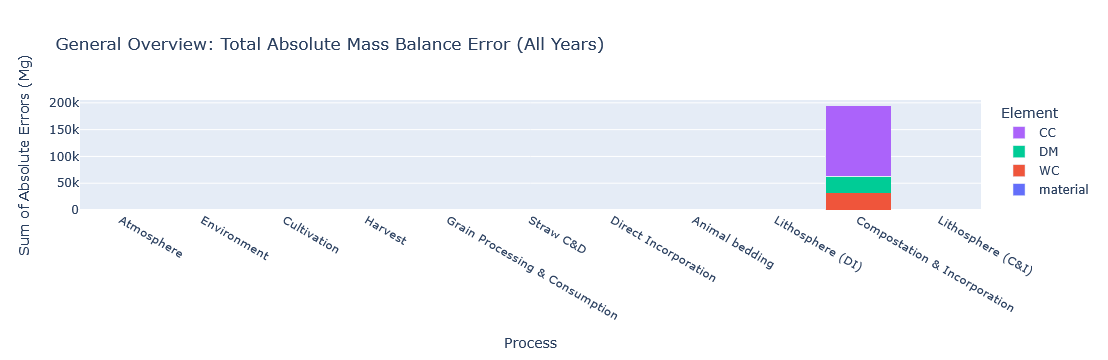

interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'marker': {'color': [#7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #7f7f7f]},
              'type': 'bar',
              'uid': '41e49e32-d7c1-4304-bcb2-5304745c03a9',
              'x': [Atmosphere, Environment, Cultivation, Harvest, Grain
                    Processing & Consumption, Straw C&D, Direct Incorporation,
                    Animal bedding, Lithosphere (DI), Compostation & Incorporation,
                    Lithosphere (C&I)],
              'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.4551915228366852e-11,
                    0.0, 0.0, 0.0]}],
    'layout': {'height': 500,
               'shapes': [{'line': {'color': 'black', 'width': 2},
                           'type': 'line',
                           'x0': -0.5,
                           'x1': 10.5,
                           'y0': 0,
                           'y1': 0}],
   

In [22]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION (BASELINE)")
print("="*60)
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)

# 3. Baseline Visualization

In [23]:
print("\n" + "="*60)
print("📊 VISUALIZATION (BASELINE)")
print("="*60)


📊 VISUALIZATION (BASELINE)


In [24]:
# ## 3.1 Traditional Sankey Diagram
print("\n--- Traditional Sankey Diagram ---")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


--- Traditional Sankey Diagram ---


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4],
                       'source': [0, 1, 2, 3, 3, 4, 4, 5, 6, 5, 7, 7, 8, 8, 5, 9,
                                  9, 10, 10, 9],
                       'target': [2, 2, 3, 4, 5, 0, 1, 6, 8, 7, 0, 1, 0, 1, 9, 0,
                                  1, 0, 1, 10],
                       'value': [297904.57, 423763.48, 721668.05, 342070.6557,
                                 379597.39430000004, 141206.76667296,
                                 200863.88902704, 189798.69715000002,
                                 189798.69715000002, 113879.21829, 47009.341310112,
                                 66869.87697988801, 0.0, 26571.81760100

In [25]:

# ## 3.2 Enhanced Circular Sankey Diagram
print("\n--- Enhanced Circular Sankey Diagram ---")
try:
    from plotting import plot_circular_sankey
    print("🎯 Creating enhanced circular Sankey diagram...")
    plot_circular_sankey(
        mfa_system_results=mfa_results_baseline,
        dsm_params=dsm_params,
        fomp_params=fomp_params,
        config_file=input_file  # Uses your Excel file with Part 6 visualization sheets
    )
    print("✅ Enhanced circular Sankey diagram created successfully!")
except Exception as e:
    print(f"⚠️ Enhanced Sankey diagram failed: {e}")
    print("   Falling back to traditional Sankey diagram only")


--- Enhanced Circular Sankey Diagram ---
🎯 Creating enhanced circular Sankey diagram...
📊 Loading visualization configuration from Excel...


/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



  ✅ Loaded and processed 6_1_Visualization_Processes


/home/jhamann/github/work/Biodym_JS/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



  ✅ Loaded 6_2_Visualization_Flows
  ✅ Loaded 6_3_Layout_Configuration
✅ Visualization configuration loaded successfully
📐 Window sizing from Excel: 800x600 pixels
🔍 Zoom settings from Excel:
   - Zoom Factor: 1.0 (range: 0.3-3.0)
   - Node Scale: 1.0, Flow Scale: 1.0
   - Auto Fit Frame: True, Center Diagram: True
   - Responsive: True, Auto-size: True


🎯 Calculating element-specific positions for 'material' with layout 'Circular'
  -> Found process config for ID key: 00
  -> Using element-specific positions for material: (0.1, 0.8)
  -> Found process config for ID key: 01
  -> Using element-specific positions for material: (0.1, 0.2)
  -> Found process config for ID key: 02
  -> Using element-specific positions for material: (0.2, 0.5)
  -> Found process config for ID key: 03
  -> Using element-specific positions for material: (0.3, 0.5)
  -> Found process config for ID key: 04
  -> Using element-specific positions for material: (0.4, 0.2)
  -> Found process config for ID key: 05
  -> Using element-specific positions for material: (0.4, 0.6)
  -> Found process config for ID key: 06
  -> Using element-specific positions for material: (0.6, 0.6)
  -> Found process config for ID key: 07
  -> Using element-specific positions for material: (0.5, 0.2)
  -> Found process config for ID key: 08
  -> Using element-specific positions for materi

In [26]:
# ## 3.3 Additional Visualizations
print("\n--- Additional Visualizations ---")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")
if dsm_params and dsm_details_baseline:
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
if fomp_params:
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)


--- Additional Visualizations ---


interactive(children=(Dropdown(description='Process:', options=('Atmosphere', 'Environment', 'Cultivation', 'H…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': '7bf9638a-caa5-41ff-a889-29c97c05e371',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': {'bdata': ('5V1T0t9KCUG8F9xiPmwPQc704XuEfA' ... 'i3yRBBX1Y2MQ6WEkEU6PCbOXsSQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'mode': 'lines',
              'name': 'Stock',
              'type': 'scatter',
              'uid': 'e7a1efbc-9f37-474e-8a2e-a323dcae4ab1',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x2',
              

interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': '8a1cd9b2-c653-4041-bd96-6701f457393c',
              'x': array(['Atmosphere', 'Environment', 'Lithosphere (DI)', 'Lithosphere (C&I)'],
                         dtype=object),
              'y': {'bdata': 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA=', 'dtype': 'f8'}}],
    'layout': {'font': {'family': 'Arial, sans-serif', 'size': 12},
               'showlegend': False,
               'template': '...',
               'title': {'font': {'family': 'Arial, sans-serif', 'size': 20},
                         'text': 'Stock Levels Over Time (Baseline) - MATERIAL (2025)',
                         'x': 0.5},
               'xaxis': {'linecolor': 'black',
                         'linewidth': 1,
                         'showgrid': False,
                         't

FigureWidget({
    'data': [{'hovertemplate': '<b>Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#2ca02c', 'width': 3},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Organic Matter Stock',
              'type': 'scatter',
              'uid': '563387bf-5fcf-48b1-b3f5-08acba0ee9c5',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': {'bdata': ('AAAAAAAAAABy/FAJ1+wDQaYJca3Dkx' ... 'H/YzZB8WHREQeFNkGxm3NCGU43QQ=='),
                    'dtype': 'f8'}},
             {'hovertemplate': '<b>Annual Input</b><br>Year: %{x}<br>Mass: %{y:.2f}} Mg<extra></extra>',
              'line': {'color': '#1f77b4', 'dash': 'dash', 'width': 2},
              'marker': {'size': 3},
              'mode': 'lines+markers',
       

# 4. Scenario Analysis & Comparison

In [27]:
if getattr(config_obj, 'Run_Scenario_Analysis', False):
    # Find all scenarios defined in the config object
    scenario_names_to_run = []
    for i in range(1, 10): # Check for up to 9 scenarios
        attr_name = f'Selected_Scenario_Name_{i}'
        if hasattr(config_obj, attr_name):
            scenario_name = getattr(config_obj, attr_name)
            if scenario_name and not pd.isna(scenario_name):
                scenario_names_to_run.append(scenario_name)

    if not scenario_names_to_run:
        print("⚠️ Scenario Analysis is enabled, but no scenarios are selected in the configuration.")
    else:
        print(f"Found {len(scenario_names_to_run)} scenarios to run: {scenario_names_to_run}")
        all_scenario_results = {}
        scenario_definitions = data_loader.load_scenario_definitions(all_excel_data)

        for scenario_name in scenario_names_to_run:
            print("\n" + "="*60)
            print(f"🎭 RUNNING SCENARIO: '{scenario_name}'")
            print("="*60)

            if scenario_name not in scenario_definitions:
                print(f"⚠️ WARNING: Scenario '{scenario_name}' not found in '5_1_Scenario_Manager' sheet! Skipping.")
                continue

            # Create a deep copy for each scenario run to ensure independence
            mfa_system_scenario = copy.deepcopy(mfa_system_configured)
            mfa_system_scenario = system_setup.apply_scenario(mfa_system_scenario, scenario_definitions, scenario_name)

            # Run calculation with Monte Carlo disabled for the scenario
            scenario_config_obj = copy.deepcopy(config_obj)
            scenario_config_obj.RUN_MONTE_CARLO = False
            
            mfa_results_scenario, _ = solver.run_mfa_calculation(mfa_system_scenario, dsm_params, fomp_params, scenario_config_obj)
            all_scenario_results[scenario_name] = mfa_results_scenario
            print(f"✅ Scenario '{scenario_name}' calculation completed successfully!")

        # After running all scenarios, generate the comparison plot
        if all_scenario_results:
            import importlib
            importlib.reload(plotting)
            print("\n" + "="*60)
            print("📊 MULTI-SCENARIO VS. BASELINE COMPARISON")
            print("="*60)
            plotting.plot_multi_scenario_comparison(
                baseline_results=mfa_results_baseline, 
                all_scenario_results=all_scenario_results,
                scenario_definitions=scenario_definitions
            )
            
            # Enhanced Sankey comparison for scenarios
            print("\n--- Enhanced Circular Sankey Comparison ---")
            try:
                from plotting import plot_circular_sankey
                print("🎯 Creating enhanced circular Sankey diagrams for scenario comparison...")
                
                # Show baseline with enhanced Sankey
                print("\n📊 Baseline - Enhanced Circular Sankey:")
                plot_circular_sankey(
                    mfa_system_results=mfa_results_baseline,
                    dsm_params=dsm_params,
                    fomp_params=fomp_params,
                    config_file=input_file
                )
                
                # Show first scenario with enhanced Sankey (if available)
                if scenario_names_to_run:
                    first_scenario = scenario_names_to_run[0]
                    if first_scenario in all_scenario_results:
                        print(f"\n📊 Scenario '{first_scenario}' - Enhanced Circular Sankey:")
                        plot_circular_sankey(
                            mfa_system_results=all_scenario_results[first_scenario],
                            dsm_params=dsm_params,
                            fomp_params=fomp_params,
                            config_file=input_file
                        )
                
                print("✅ Enhanced circular Sankey comparison completed!")
            except Exception as e:
                print(f"⚠️ Enhanced Sankey comparison failed: {e}")
                print("   Traditional comparison plots are still available")

# 6. Export & Final Summary

In [28]:
print("\n" + "="*60)
print("💾 EXPORTING BASELINE RESULTS")
print("="*60)


💾 EXPORTING BASELINE RESULTS


In [29]:
output_file = "data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file)
print(f"✅ Baseline results exported to: {output_file}")

--> Exporting results to 'data/02_output/results_scientific_baseline.xlsx'...
✅ Baseline results exported to: data/02_output/results_scientific_baseline.xlsx


# 7. Monte Carlo Analysis (Baseline)

In [30]:
print("\n" + "="*60)
print("🎲 MONTE CARLO SIMULATION (BASELINE)")
print("="*60)


🎲 MONTE CARLO SIMULATION (BASELINE)


In [31]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from plotting.mc_visuals import plot_interactive_mc_histogram, plot_interactive_tornado
        mc_results = run_mc_simulation(mfa_system_configured, input_data, dsm_params, fomp_params, config_obj)
        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed for baseline")
            plot_interactive_mc_histogram(mc_results)
            plot_interactive_tornado(mc_results)
    except Exception as e:
        print(f"⚠️ Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")


[MC] Parameter Validation Warnings:
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']


[MC] Running Monte Carlo simulation with 25 iterations...
[MC] Using 2 validated parameters...
  Running iteration 1/25...
   Total carbon output: 1247333.26
   Total environmental output: 1351277.70
    Protected FOMP output flow: F_08_00
    Protected FOMP output flow: F_08_01
   Total carbon output: 17621.99
   Total environmental output: 19090.49
    Protected FOMP output flow: F_10_00
    Protected FOMP output flow: F_10_01
--> Processing stock-outflow transfer coefficients...
--> No stock-outflow TCs found in system setup
--> Stock-outflow TC processing finished.
--> Calculating final stock balances for ALL processes...
--> Stock balance calculation finished.
  Running iteration 2/25...
   Total carbon output: 1646012.74
   Total environmental output: 1783180.4

In [32]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE


In [33]:
# ## 7.1 Visualization Summary
print("\n📊 VISUALIZATION SUMMARY")
print("="*30)
print("✅ Traditional Sankey Diagram - Standard left-to-right flow visualization")
print("✅ Enhanced Circular Sankey - Optimized for circular/recycling systems")
print("✅ Process Dynamics - Inflow, stock, and outflow analysis")
print("✅ Stock Bar Chart - Stock levels over time")
if dsm_params and dsm_details_baseline:
    print("✅ DSM Stock Details - Dynamic stock model analysis")
if fomp_params:
    print("✅ FOMP Stock Details - First-order material processing analysis")
if config_obj.RUN_MONTE_CARLO:
    print("✅ Monte Carlo Analysis - Uncertainty quantification")
if getattr(config_obj, 'Run_Scenario_Analysis', False):
    print("✅ Scenario Comparison - Multi-scenario analysis")


📊 VISUALIZATION SUMMARY
✅ Traditional Sankey Diagram - Standard left-to-right flow visualization
✅ Enhanced Circular Sankey - Optimized for circular/recycling systems
✅ Process Dynamics - Inflow, stock, and outflow analysis
✅ Stock Bar Chart - Stock levels over time
✅ FOMP Stock Details - First-order material processing analysis
✅ Monte Carlo Analysis - Uncertainty quantification


In [34]:
print("\n🎯 Enhanced Sankey Features:")
print("   - Circular layout for recycling systems")
print("   - Custom colors and positioning from Excel configuration")
print("   - Automatic detection of circular flows")
print("   - Interactive controls for year, element, and process selection")
print("   - Export functionality for high-quality visualizations")


🎯 Enhanced Sankey Features:
   - Circular layout for recycling systems
   - Custom colors and positioning from Excel configuration
   - Automatic detection of circular flows
   - Interactive controls for year, element, and process selection
   - Export functionality for high-quality visualizations


In [35]:
print("\n📝 Configuration:")
print(f"   - Visualization settings: Part 6 sheets in {input_file}")
print(f"   - Process colors: 6_1_Visualization_Processes")
print(f"   - Flow colors: 6_2_Visualization_Flows")
print(f"   - Layout settings: 6_3_Layout_Configuration")
print(f"   - Element colors: 6_4_CL_Visualisation")


📝 Configuration:
   - Visualization settings: Part 6 sheets in data/01_input/250910_CS1_Wheat_Straw_v3.xlsx
   - Process colors: 6_1_Visualization_Processes
   - Flow colors: 6_2_Visualization_Flows
   - Layout settings: 6_3_Layout_Configuration
   - Element colors: 6_4_CL_Visualisation
